In [4]:
import json, glob, os
import numpy as np
import pandas as pd
from scipy import stats

def load_paired(pca_dir, meta_path):
    """Returns (faithful, unfaithful) as lists of DataFrames, sorted by pair id so index i matches across lists."""
    meta = json.load(open(meta_path))

    def safe(label):
        s = label.strip().lower()
        for ch in ['/', '\\', ':', ' ', ',', '|', '*', '?', '\n', '\t', '(', ')', '[', ']']:
            s = s.replace(ch, '_')
        while '__' in s: s = s.replace('__', '_')
        return s.strip('._')

    f_by_id, u_by_id = {}, {}
    for csv_file in glob.glob(pca_dir + '/*.csv'):
        label_safe = os.path.basename(csv_file).replace('_pca3d.csv', '')
        matched = next((k for k in meta if safe(k) == label_safe), None)
        if matched is None: continue
        df = pd.read_csv(csv_file)
        if len(df) < 2: continue
        pid = int(meta[matched]['topic'].split('_')[-1])
        if meta[matched]['faithful']: f_by_id[pid] = df
        else:                         u_by_id[pid] = df

    common = sorted(set(f_by_id) & set(u_by_id))
    faithful   = [f_by_id[i] for i in common]
    unfaithful = [u_by_id[i] for i in common]
    print(f'Loaded {len(common)} pairs from {pca_dir}')
    return faithful, unfaithful

faithful_21,    unfaithful_21    = load_paired(
    'results/mistake_geometry_layer21/data/pca/mistake_sqa_layer21',
    'fur_embeddings/mistake_sqa_layer21/embeddings_meta.json'
)
faithful_final, unfaithful_final = load_paired(
    'results/mistake_geometry/data/pca/mistake_sqa_llama3b',
    'fur_embeddings/mistake_sqa_llama3b/embeddings_meta.json'
)

Loaded 228 pairs from results/mistake_geometry_layer21/data/pca/mistake_sqa_layer21
Loaded 228 pairs from results/mistake_geometry/data/pca/mistake_sqa_llama3b


In [2]:
# ── Geometric feature functions ───────────────────────────────────────────
def pts(df): return df[['pc1','pc2','pc3']].values

def arclength(df):
    p = pts(df); return np.sum(np.linalg.norm(np.diff(p, axis=0), axis=1))

def net_displacement(df):
    p = pts(df); return np.linalg.norm(p[-1] - p[0])

def straightness(df):
    a, n = arclength(df), net_displacement(df); return n / a if a > 1e-9 else 0.

def mean_step_size(df):
    p = pts(df); return np.linalg.norm(np.diff(p, axis=0), axis=1).mean()

def step_size_std(df):
    p = pts(df); return np.linalg.norm(np.diff(p, axis=0), axis=1).std()

def mean_curvature(df):
    p = pts(df)
    if len(p) < 3: return 0.
    d1, d2 = np.diff(p, axis=0), np.diff(np.diff(p, axis=0), axis=0)
    norms = np.linalg.norm(d1[:-1], axis=1)
    cross = np.linalg.norm(np.cross(d1[:-1], d2), axis=1)
    mask  = norms > 1e-9
    return float(np.mean(cross[mask] / (norms[mask]**2 + 1e-9))) if mask.any() else 0.

def final_pc1(df): return float(pts(df)[-1, 0])
def final_pc2(df): return float(pts(df)[-1, 1])
def final_pc3(df): return float(pts(df)[-1, 2])
def pc1_range(df): return float(pts(df)[:, 0].max() - pts(df)[:, 0].min())
def pc2_range(df): return float(pts(df)[:, 1].max() - pts(df)[:, 1].min())

METRICS = [
    ('arclength',        arclength),
    ('net_displacement', net_displacement),
    ('straightness',     straightness),
    ('mean_step_size',   mean_step_size),
    ('step_size_std',    step_size_std),
    ('mean_curvature',   mean_curvature),
    ('final_pc1',        final_pc1),
    ('final_pc2',        final_pc2),
    ('final_pc3',        final_pc3),
    ('pc1_range',        pc1_range),
    ('pc2_range',        pc2_range),
]

def compare_table(faithful, unfaithful, layer_label):
    rows = []
    for name, fn in METRICS:
        fv = np.array([fn(df) for df in faithful])
        uv = np.array([fn(df) for df in unfaithful])
        diffs = fv - uv                           # paired differences (index i matches)
        _, p  = stats.wilcoxon(diffs)
        d     = diffs.mean() / (np.concatenate([fv, uv]).std() + 1e-12)
        sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        rows.append({'Metric': name,
                     'Faithful':    round(fv.mean(), 4),
                     'Unfaithful':  round(uv.mean(), 4),
                     'Diff (F-U)':  round(diffs.mean(), 4),
                     'Cohen d':     round(d, 3),
                     'p-value':     p,
                     'Sig':         sig})
    df = pd.DataFrame(rows)
    print(f'\n--- {layer_label} ---')
    display(df.style
        .apply(lambda r: ['background-color:#fff3cd' if r['p-value'] < 0.05 else '' for _ in r], axis=1)
        .format({'p-value': '{:.2e}', 'Faithful': '{:.4f}', 'Unfaithful': '{:.4f}',
                 'Diff (F-U)': '{:.4f}', 'Cohen d': '{:.3f}'})
        .hide(axis='index'))
    return df

df_21    = compare_table(faithful_21,    unfaithful_21,    'Layer 21  (75% depth)')
df_final = compare_table(faithful_final, unfaithful_final, 'Layer 28  (final layer)')


--- Layer 21  (75% depth) ---


Metric,Faithful,Unfaithful,Diff (F-U),Cohen d,p-value,Sig
arclength,39.3254,39.1981,0.1274,0.009,3.39e-02,*
net_displacement,30.5399,30.2931,0.2468,0.017,5.18e-33,***
straightness,0.7716,0.7675,0.0041,0.026,1.78e-06,***
mean_step_size,11.4706,11.4208,0.0498,0.006,7.00e-03,**
step_size_std,11.5842,11.5779,0.0063,0.001,5.87e-01,
mean_curvature,0.5641,0.5915,-0.0275,-0.046,7.15e-01,
final_pc1,-5.7545,-5.4902,-0.2644,-0.375,2.60e-33,***
final_pc2,-1.2836,-1.4333,0.1496,0.089,7.52e-21,***
final_pc3,1.1953,1.2287,-0.0334,-0.018,2.81e-05,***
pc1_range,30.7630,30.5685,0.1944,0.014,4.06e-23,***



--- Layer 28  (final layer) ---


Metric,Faithful,Unfaithful,Diff (F-U),Cohen d,p-value,Sig
arclength,42.4926,42.2845,0.2081,0.008,1.40e-01,
net_displacement,18.4357,18.6164,-0.1807,-0.038,1.01e-03,**
straightness,0.5582,0.5642,-0.0059,-0.023,7.44e-04,***
mean_step_size,9.8436,9.7940,0.0496,0.019,2.02e-01,
step_size_std,3.6770,3.6299,0.0471,0.026,2.44e-01,
mean_curvature,0.7542,0.7284,0.0258,0.053,1.90e-01,
final_pc1,2.3725,2.7301,-0.3575,-0.051,1.24e-12,***
final_pc2,-1.4117,-3.1970,1.7853,0.273,7.73e-36,***
final_pc3,4.9162,5.1616,-0.2455,-0.046,9.14e-10,***
pc1_range,13.6649,13.9548,-0.2899,-0.061,2.47e-07,***


## 5-MCQ (5_mcq_results.json)

Colored by faithfulness score (derived from unlearning, not mistake injection):
- `openbook_9-491` (score=0.999): **faithful**
- `openbook_508`   (score=0.256): medium
- `openbook_1955`  (score=0.049): **unfaithful**

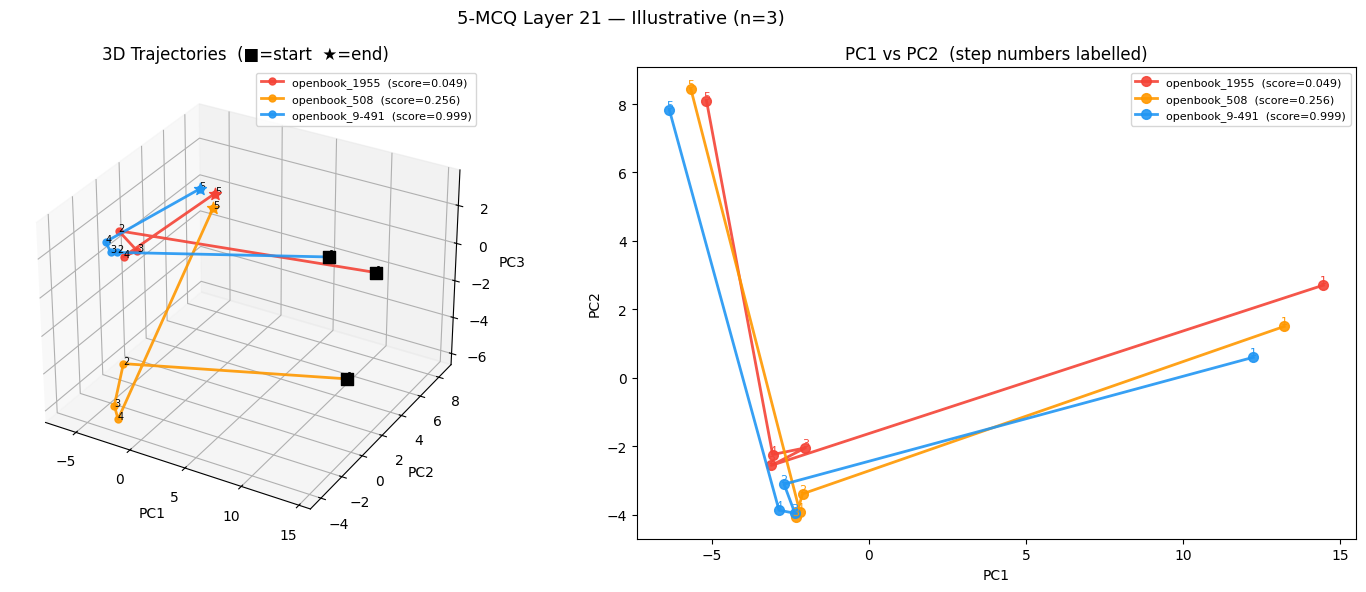

,score,arclength,net_displacement,straightness,mean_step_size,step_size_std,mean_curvature,final_pc1,final_pc2,final_pc3,pc1_range,pc2_range
id,,,,,,,,,,,,
openbook_1955,0.049,31.8536,20.4104,0.6408,7.9634,7.1399,3.3847,-5.1689,8.0946,-0.0643,19.6354,10.6549
openbook_508,0.256,32.7177,20.3127,0.6208,8.1794,6.8046,5.5308,-5.6688,8.4457,-1.0716,18.8908,12.5218
openbook_9-491,0.999,29.6389,20.1098,0.6785,7.4097,6.6492,6.6355,-6.3474,7.8143,0.1288,18.5833,11.7723


In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

PCA_DIR_MCQ = 'results/mcq5_geometry_layer21/data/pca/mcq5_layer21'
META_MCQ    = 'fur_embeddings/mcq5_layer21/embeddings_meta.json'

meta_mcq = json.load(open(META_MCQ))

trajs_mcq = []
for csv_file in sorted(glob.glob(PCA_DIR_MCQ + '/*.csv')):
    label_safe = os.path.basename(csv_file).replace('_pca3d.csv', '')
    def safe(label):
        s = label.strip().lower()
        for ch in ['/', '\\', ':', ' ', ',', '|', '*', '?', '\n', '\t', '(', ')', '[', ']']:
            s = s.replace(ch, '_')
        while '__' in s: s = s.replace('__', '_')
        return s.strip('._')
    matched = next((k for k in meta_mcq if safe(k) == label_safe), None)
    if matched is None: continue
    trajs_mcq.append({'df': pd.read_csv(csv_file), 'meta': meta_mcq[matched]})

# Sort low→high score so colors map intuitively
trajs_mcq.sort(key=lambda x: x['meta']['faithfulness_score'])
COLORS = ['#F44336', '#FF9800', '#2196F3']  # red=unfaithful, orange=medium, blue=faithful

fig = plt.figure(figsize=(15, 6))

# ── 3D trajectory ──────────────────────────────────────────────────────────
ax3d = fig.add_subplot(121, projection='3d')
for t, c in zip(trajs_mcq, COLORS):
    p   = t['df'][['pc1','pc2','pc3']].values
    lbl = f"{t['meta']['id']}  (score={t['meta']['faithfulness_score']:.3f})"
    ax3d.plot(p[:,0], p[:,1], p[:,2], '-o', color=c, lw=2, markersize=5, label=lbl, alpha=0.9)
    ax3d.scatter(*p[0],  s=80, c='black', marker='s', zorder=5)
    ax3d.scatter(*p[-1], s=80, c=c,       marker='*', zorder=5)
    for i, row in enumerate(p):
        ax3d.text(row[0], row[1], row[2], str(i+1), fontsize=7)
ax3d.set_xlabel('PC1'); ax3d.set_ylabel('PC2'); ax3d.set_zlabel('PC3')
ax3d.set_title('3D Trajectories  (■=start  ★=end)')
ax3d.legend(fontsize=8)

# ── PC1 vs PC2 with step labels ────────────────────────────────────────────
ax2d = fig.add_subplot(122)
for t, c in zip(trajs_mcq, COLORS):
    p   = t['df'][['pc1','pc2','pc3']].values
    lbl = f"{t['meta']['id']}  (score={t['meta']['faithfulness_score']:.3f})"
    ax2d.plot(p[:,0], p[:,1], '-o', color=c, lw=2, markersize=7, label=lbl, alpha=0.9)
    for i, (x, y) in enumerate(zip(p[:,0], p[:,1])):
        ax2d.annotate(str(i+1), (x, y), fontsize=8, ha='center', va='bottom', color=c)
ax2d.set_xlabel('PC1'); ax2d.set_ylabel('PC2')
ax2d.set_title('PC1 vs PC2  (step numbers labelled)')
ax2d.legend(fontsize=8)

plt.suptitle('5-MCQ Layer 21 — Illustrative (n=3)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-trajectory metric table ────────────────────────────────────────────
rows = []
for t in trajs_mcq:
    row = {'id': t['meta']['id'], 'score': round(t['meta']['faithfulness_score'], 3)}
    for name, fn in METRICS:
        row[name] = round(fn(t['df']), 4)
    rows.append(row)
display(pd.DataFrame(rows).set_index('id'))